# 05 · Looking inside: attention maps (paper Figs. 3 & 6)

> **Paper:** §4.2 "Ablations", Fig. 3 (encoder self-attention), Fig. 6 (decoder attention)

We've traced every tensor. Now let's see what the model actually *looks at*. We'll reproduce two figures from the paper on our own image, using PyTorch **forward hooks** — the standard tool for extracting intermediate values without editing the model.

The finding, in one line: **the encoder separates instances; the decoder then traces their edges.**

In [1]:
%matplotlib inline
import torch, matplotlib.pyplot as plt
from detr_utils import *   # noqa: F403

device = get_device()
model = load_pretrained_detr(device=device)
im = load_image("cats")
print("device:", device, "| image:", im.size)

/Users/jaeyongjung/Desktop/detr/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/jaeyongjung/Desktop/detr/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


device: mps | image: (640, 480)


## 1. Capturing attention with forward hooks

`nn.MultiheadAttention` returns `(output, attention_weights)`, but DETR's code keeps only `[0]` and throws the weights away. A **forward hook** intercepts the return value so we can keep both — no changes to `models/transformer.py` required.

In [2]:
conv_features, enc_attn, dec_attn = [], [], []

hooks = [
    # feature-map size, so we know how to reshape a flat 850 back into a 2-D grid
    model.backbone[-2].register_forward_hook(
        lambda m, i, o: conv_features.append(o['0'].tensors.shape)),
    # last ENCODER layer: image tokens attending to image tokens
    model.transformer.encoder.layers[-1].self_attn.register_forward_hook(
        lambda m, i, o: enc_attn.append(o[1])),
    # last DECODER layer: object queries attending to the encoder memory
    model.transformer.decoder.layers[-1].multihead_attn.register_forward_hook(
        lambda m, i, o: dec_attn.append(o[1])),
]

with torch.no_grad():
    outputs = model(default_transform(im).unsqueeze(0).to(device))

for h in hooks:
    h.remove()          # ALWAYS remove hooks -- they leak memory and slow later runs

_, _, Hf, Wf = conv_features[0]
enc = enc_attn[0][0].cpu()          # shape: (850, 850)   token -> token
dec = dec_attn[0][0].cpu()          # shape: (100, 850)   query -> token

print(f"feature grid      : {Hf} x {Wf} = {Hf*Wf} tokens")
print(f"encoder attention : {tuple(enc.shape)}  every token's view of every other token")
print(f"decoder attention : {tuple(dec.shape)}  every query's view of the image")
print(f"\nrows are softmax distributions -> each sums to 1: {float(enc[0].sum()):.4f}")

feature grid      : 25 x 34 = 850 tokens
encoder attention : (850, 850)  every token's view of every other token
decoder attention : (100, 850)  every query's view of the image

rows are softmax distributions -> each sums to 1: 1.0000


## 2. Encoder self-attention (Fig. 3)

Pick a few **reference points** in the image. For each, show which other pixels its token attends to. Paper's caption: *"The encoder is able to separate individual instances."*

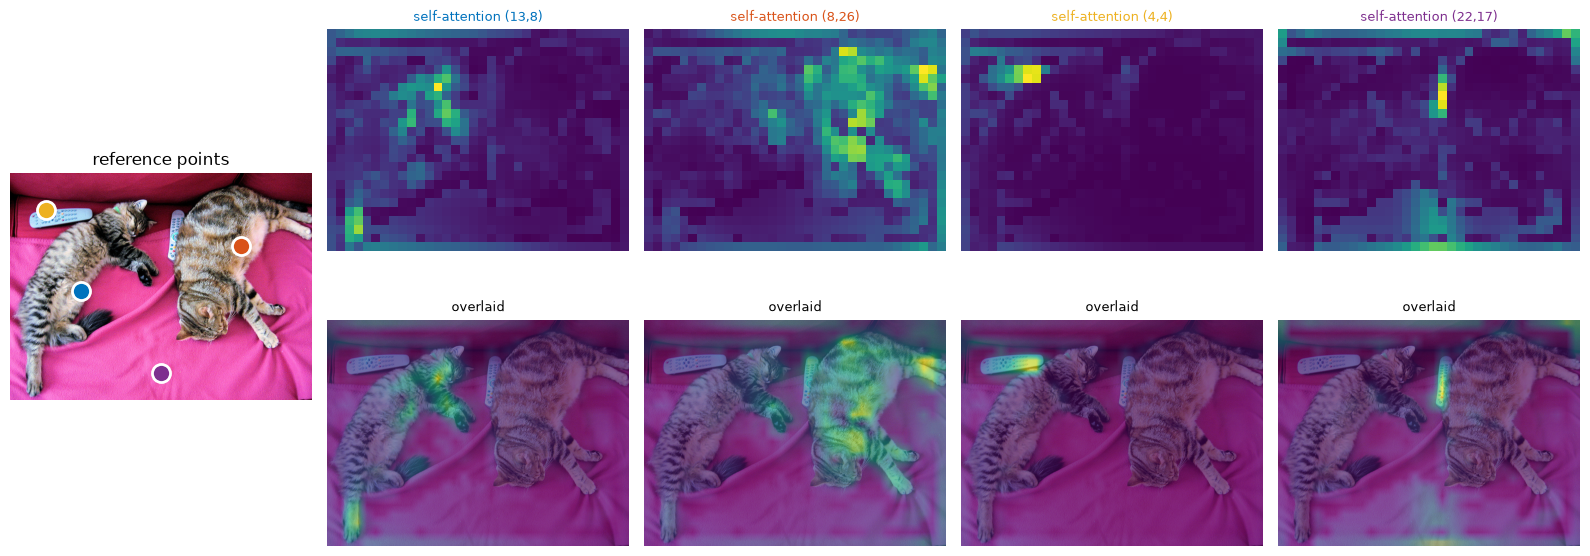

In [3]:
# reference points as (row, col) in the FEATURE grid, not pixels
ref_points = [(int(Hf*0.55), int(Wf*0.25)),    # left cat
              (int(Hf*0.35), int(Wf*0.78)),    # right cat
              (int(Hf*0.18), int(Wf*0.14)),    # left remote
              (int(Hf*0.90), int(Wf*0.50))]    # couch / background

fig, axes = plt.subplots(2, len(ref_points)+1, figsize=(16, 6),
                         gridspec_kw={"height_ratios": [1, 1]})
gs = axes[0, 0].get_gridspec()
for ax in axes[:, 0]:
    ax.remove()
axbig = fig.add_subplot(gs[:, 0])
axbig.imshow(im); axbig.axis("off"); axbig.set_title("reference points")

for k, (r, c) in enumerate(ref_points):
    # convert feature-grid coords -> pixel coords for the marker
    axbig.plot(c / Wf * im.size[0], r / Hf * im.size[1], "o",
               color=COLORS[k], markersize=13, markeredgecolor="w", markeredgewidth=2)

for k, (r, c) in enumerate(ref_points):
    idx = r * Wf + c                       # flatten (row, col) -> token index
    a = enc[idx].reshape(Hf, Wf)           # that token's attention over the grid
    ax = axes[0, k+1]
    ax.imshow(a, cmap="viridis"); ax.axis("off")
    ax.set_title(f"self-attention ({r},{c})", fontsize=9, color=COLORS[k])
    ax2 = axes[1, k+1]
    ax2.imshow(im)
    ax2.imshow(torch.nn.functional.interpolate(
        a[None, None], size=(im.size[1], im.size[0]), mode="bilinear")[0, 0],
        cmap="viridis", alpha=0.65)
    ax2.axis("off"); ax2.set_title("overlaid", fontsize=9)
plt.tight_layout(); plt.show()

Look at what happened: a point on the **left cat** lights up the left cat *and essentially nothing else* — not the right cat, even though both are cats with near-identical texture. The encoder has already grouped pixels into **instances**, before any box is predicted.

This is why removing the encoder costs 3.9 AP overall and **6.0 AP on large objects** (Table 2). A large object spans dozens of grid cells; only global self-attention can bind them into one thing.

> *"The encoder seems to separate instances already, which likely simplifies object extraction and localization for the decoder."* — §4.2

## 3. Decoder cross-attention (Fig. 6)

Now the other half: for each *detected object*, which pixels did its query read from?

In [4]:
probs = outputs["pred_logits"].softmax(-1)[0, :, :-1].cpu()   # (100, 91)
keep = probs.max(-1).values > 0.9
kept_idx = keep.nonzero().flatten().tolist()
boxes = rescale_bboxes(outputs["pred_boxes"][0, keep].cpu(), im.size)

print(f"{len(kept_idx)} detections, from query slots {kept_idx}")
for q, p in zip(kept_idx, probs[keep]):
    print(f"   query {q:3d}: {COCO_CLASSES[p.argmax()]:<8} {p.max():.3f}")

5 detections, from query slots [37, 57, 59, 61, 98]
   query  37: remote   0.998
   query  57: remote   0.996
   query  59: couch    0.995
   query  61: cat      0.999
   query  98: cat      0.999


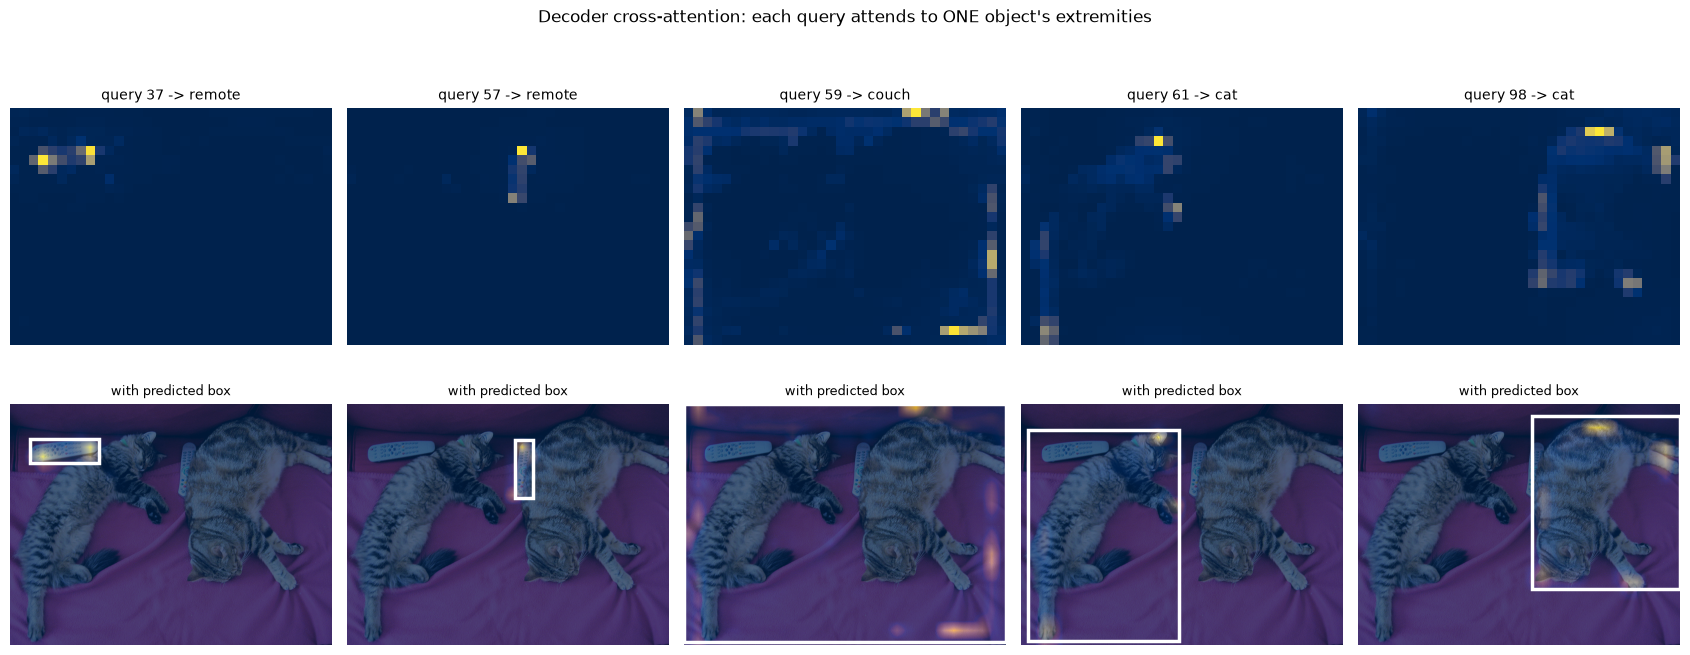

In [5]:
n = len(kept_idx)
fig, axes = plt.subplots(2, n, figsize=(3.4*n, 7))
axes = axes.reshape(2, n)

for j, (q, box) in enumerate(zip(kept_idx, boxes)):
    a = dec[q].reshape(Hf, Wf)                 # this query's attention over the image
    axes[0, j].imshow(a, cmap="cividis"); axes[0, j].axis("off")
    lbl = COCO_CLASSES[probs[q].argmax()]
    axes[0, j].set_title(f"query {q} -> {lbl}", fontsize=10)

    axes[1, j].imshow(im)
    axes[1, j].imshow(torch.nn.functional.interpolate(
        a[None, None], size=(im.size[1], im.size[0]), mode="bilinear")[0, 0],
        cmap="cividis", alpha=0.7)
    x0, y0, x1, y1 = box.tolist()
    axes[1, j].add_patch(plt.Rectangle((x0, y0), x1-x0, y1-y0,
                          fill=False, color="w", lw=2.5))
    axes[1, j].axis("off"); axes[1, j].set_title("with predicted box", fontsize=9)

plt.suptitle("Decoder cross-attention: each query attends to ONE object's extremities", y=1.0)
plt.tight_layout(); plt.show()

Two things to notice:

1. **Each query attends to exactly one object.** Query 61's map covers the left cat only; query 98's covers the right cat only. This is the set prediction from notebook `04`, visible in the attention: one query, one object.
2. **Attention concentrates on edges and extremities** — paws, ear tips, the ends of the remotes. Paper: *"decoder attention is fairly local, meaning that it mostly attends to object extremities such as heads or legs."*

That division of labor is the whole architecture in a sentence: the encoder does the **global** work of separating instances; the decoder does the **local** work of finding each one's boundary, which is precisely what you need to regress a box.

## 4. What do the ∅ queries look at?

95 queries predicted "no object". Are they attending to nothing, or somewhere useless?

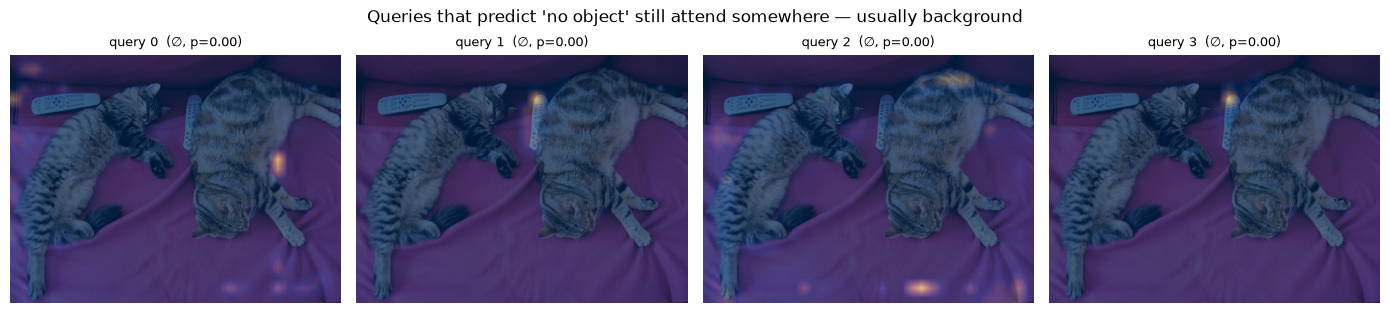

In [6]:
empty_idx = (~keep).nonzero().flatten()[:4].tolist()
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, q in zip(axes, empty_idx):
    ax.imshow(im)
    a = dec[q].reshape(Hf, Wf)
    ax.imshow(torch.nn.functional.interpolate(
        a[None, None], size=(im.size[1], im.size[0]), mode="bilinear")[0, 0],
        cmap="cividis", alpha=0.7)
    ax.axis("off")
    ax.set_title(f"query {q}  (∅, p={probs[q].max():.2f})", fontsize=9)
plt.suptitle("Queries that predict 'no object' still attend somewhere — usually background")
plt.tight_layout(); plt.show()

They still attend somewhere (attention rows must sum to 1 — a softmax can't abstain). But the content they gather doesn't produce a confident class, so `class_embed` routes them to `∅`. The query is "asking its question" and getting the answer *"nothing here."*

## 5. Attention sharpens across decoder layers

Capture the cross-attention at every layer and watch one object's map tighten.

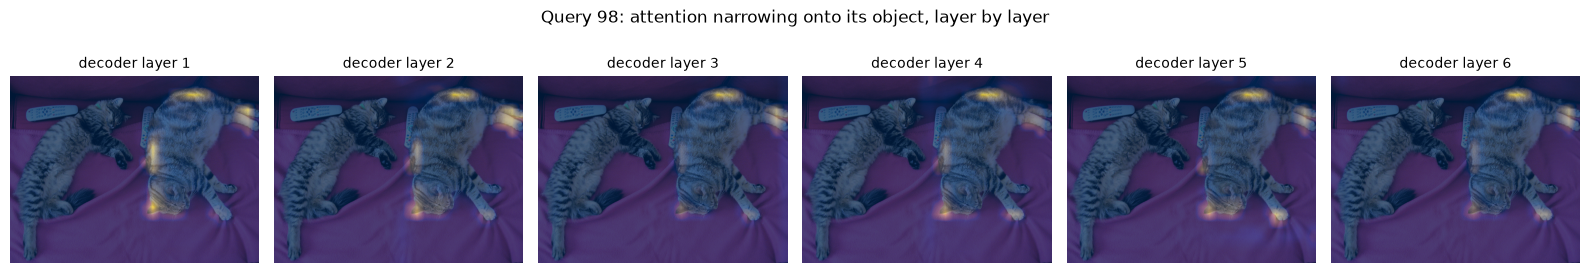

In [7]:
per_layer = []
hooks = [l.multihead_attn.register_forward_hook(
            lambda m, i, o: per_layer.append(o[1][0].cpu()))
         for l in model.transformer.decoder.layers]
with torch.no_grad():
    _ = model(default_transform(im).unsqueeze(0).to(device))
for h in hooks: h.remove()

q = kept_idx[-1]
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for L, ax in enumerate(axes):
    ax.imshow(im)
    a = per_layer[L][q].reshape(Hf, Wf)
    ax.imshow(torch.nn.functional.interpolate(
        a[None, None], size=(im.size[1], im.size[0]), mode="bilinear")[0, 0],
        cmap="cividis", alpha=0.7)
    ax.axis("off"); ax.set_title(f"decoder layer {L+1}", fontsize=10)
plt.suptitle(f"Query {q}: attention narrowing onto its object, layer by layer")
plt.tight_layout(); plt.show()

Early layers attend broadly (the query hasn't found its object yet); later layers lock on. This is the visual counterpart of the AP curve in Fig. 4, where accuracy climbs +8.2 AP from decoder layer 1 to layer 6.

## What's next

`06` is the payoff: train DETR from scratch on a tiny dataset and watch the matching loss do its work.

### Try it yourself

- Change `ref_points` to sit on the *couch*. Does the encoder group the whole couch, or fragment it?
- Run all of this on `load_image("street")` — a busier scene with many small objects. Is instance separation as clean?
- `enc` is `(850, 850)`. Compute `enc.sum(0)` and reshape to `(Hf, Wf)`: which parts of the image are attended to *most*, by everything?
- Attention here is averaged over all 8 heads (that's what `nn.MultiheadAttention` returns by default). Individual heads specialize — extracting them requires `need_weights=True, average_attn_weights=False`.